# Classic NLP baseline — TF-IDF + classifier

Companion to `sentiment_index.ipynb`: uses the full accumulated historical dataset (`data_labeled.csv`, all months combined) for training the classic baseline.

**Ground truth:** the LLM's own labels from `sentiment_index.ipynb`, saved in `data_labeled.csv`.

In [1]:
# Same labeled dataset as the LLM notebook (labels come from its own classification, saved to data_labeled.csv).
import pandas as pd

df = pd.read_csv("data_labeled.csv")
df["text"] = df["titulo"] + ". " + df["contenido"]
print(df.shape)
df["sentiment"].value_counts()

(93, 6)


sentiment
negativo    41
positivo    38
neutral     14
Name: count, dtype: int64

In [2]:
# TF-IDF + Multinomial Naive Bayes, the classic bag-of-words baseline.
# Trained on the full historical dataset (all months combined, 93 items) —
# stratified 5-fold CV so every item gets scored once as held-out.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Spanish stopwords (no built-in list in scikit-learn's TfidfVectorizer; a compact one is enough here)
SPANISH_STOPWORDS = [
    "a","al","algo","algunas","algunos","ante","antes","como","con","contra","cual","cuando",
    "de","del","desde","donde","durante","e","el","ella","ellas","ellos","en","entre","era",
    "esa","esas","ese","eso","esos","esta","estas","este","esto","estos","ha","hay","la","las",
    "lo","los","mas","más","me","mi","mientras","muy","no","nos","o","os","otra","otras","otro",
    "otros","para","pero","poco","por","porque","que","qué","se","sin","sobre","solo","su","sus",
    "tambien","también","te","tiene","tienen","todo","todos","tras","tu","tus","un","una","uno",
    "unos","y","ya","él","esta",
]

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=SPANISH_STOPWORDS, max_features=2000, ngram_range=(1, 2))),
    ("clf", MultinomialNB()),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipeline, df["text"], df["sentiment"], cv=cv)

print(classification_report(df["sentiment"], y_pred, zero_division=0))

              precision    recall  f1-score   support

    negativo       0.56      0.83      0.67        41
     neutral       0.00      0.00      0.00        14
    positivo       0.56      0.47      0.51        38

    accuracy                           0.56        93
   macro avg       0.37      0.43      0.39        93
weighted avg       0.48      0.56      0.50        93



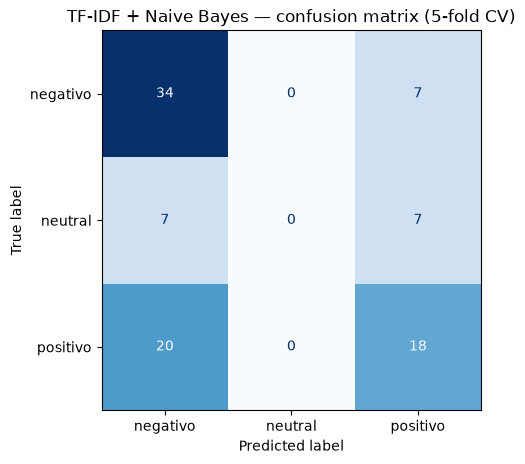

In [3]:
# Confusion matrix — rows are the LLM's real label, columns are what this model predicted.
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

labels_order = ["negativo", "neutral", "positivo"]
cm = confusion_matrix(df["sentiment"], y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=labels_order).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("TF-IDF + Naive Bayes — confusion matrix (5-fold CV)")
plt.tight_layout()
plt.savefig("tfidf_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [4]:
# Unlike an LLM call, you can open this model and see exactly which words drove each class.
import numpy as np

# Fit once on the full data (for interpretation only — the CV above is what's reported as performance)
pipeline.fit(df["text"], df["sentiment"])
vectorizer = pipeline.named_steps["tfidf"]
clf = pipeline.named_steps["clf"]
feature_names = np.array(vectorizer.get_feature_names_out())

for i, class_label in enumerate(clf.classes_):
    top_idx = np.argsort(clf.feature_log_prob_[i])[-12:][::-1]
    print(f"\n{class_label.upper()}:", ", ".join(feature_names[top_idx]))


NEGATIVO: es, huila, energía, inflación, millones, colombia, recursos, nacional, emergencia, gobierno, turismo, niño

NEUTRAL: salario, presupuesto, mínimo, proyecto, reforma, 2027, gobierno, salario mínimo, pensional, predial, impuesto, impuestos

POSITIVO: vivienda, huila, gobierno, es, trimestre, tasa, colombia, julio, laboral, mercado, precios, país
